Business Problem
---------------------
The primary objective of this project is to develop and compare multiple machine learning classification models to predict the probability of credit card default. The project focuses on understanding customer behavior through exploratory data analysis, performing appropriate data preprocessing, evaluating different algorithms, and selecting the best-performing model based on suitable evaluation metrics. The insights obtained from the analysis can assist financial institutions in reducing credit risk and improving decision-making during credit approval and customer monitoring.

Objective
---------
The primary objective of this project is to develop and compare multiple machine learning classification models to predict the probability of credit card default. The project focuses on understanding customer behavior through exploratory data analysis, performing appropriate data preprocessing, evaluating different algorithms, and selecting the best-performing model based on suitable evaluation metrics. The insights obtained from the analysis can assist financial institutions in reducing credit risk and improving decision-making during credit approval and customer monitoring.

## Dataset Description

- **ID:** ID of each client.
- **LIMIT_BAL:** Amount of given credit in NT dollars (includes individual and family/supplementary credit).
- **SEX:** Gender (1 = Male, 2 = Female).
- **EDUCATION:** Education level (1 = Graduate School, 2 = University, 3 = High School, 4 = Others, 5 = Unknown, 6 = Unknown).
- **MARRIAGE:** Marital status (1 = Married, 2 = Single, 3 = Others).
- **AGE:** Age of the client in years.
- **PAY_0:** Repayment status in September 2005 (-1 = Pay duly, 1 = One-month delay, 2 = Two-month delay, …, 8 = Eight-month delay, 9 = Nine months or more delay).
- **PAY_2:** Repayment status in August 2005 (same scale as PAY_0).
- **PAY_3:** Repayment status in July 2005 (same scale as PAY_0).
- **PAY_4:** Repayment status in June 2005 (same scale as PAY_0).
- **PAY_5:** Repayment status in May 2005 (same scale as PAY_0).
- **PAY_6:** Repayment status in April 2005 (same scale as PAY_0).
- **BILL_AMT1:** Bill statement amount in September 2005 (NT dollars).
- **BILL_AMT2:** Bill statement amount in August 2005 (NT dollars).
- **BILL_AMT3:** Bill statement amount in July 2005 (NT dollars).
- **BILL_AMT4:** Bill statement amount in June 2005 (NT dollars).
- **BILL_AMT5:** Bill statement amount in May 2005 (NT dollars).
- **BILL_AMT6:** Bill statement amount in April 2005 (NT dollars).
- **PAY_AMT1:** Previous payment amount in September 2005 (NT dollars).
- **PAY_AMT2:** Previous payment amount in August 2005 (NT dollars).
- **PAY_AMT3:** Previous payment amount in July 2005 (NT dollars).
- **PAY_AMT4:** Previous payment amount in June 2005 (NT dollars).
- **PAY_AMT5:** Previous payment amount in May 2005 (NT dollars).
- **PAY_AMT6:** Previous payment amount in April 2005 (NT dollars).
- **default.payment.next.month:** Default payment status (1 = Yes, 0 = No).

1)Importing the Libraries
-----------------------

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

2)Data Understanding
-------------------

In [2]:
df=pd.read_csv(r"D:\FROM E\imarticus learning courses\Capstone Project 1\archive\UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.shape

(30000, 25)

In [4]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 2.1 Checking Missing Values

In [7]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

### 2.2 Checking Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

### 2.3 Target Variable Distribution

In [9]:
df['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

In [10]:
df['default.payment.next.month'].value_counts(normalize=True)*100

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

## 3. Data Cleaning

3.1 Renaming the target variable

In [11]:
df.rename(columns={'default.payment.next.month':'Default'},inplace=True)

In [12]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


3.2 Removing ID columns

In [13]:
df['ID'].nunique()

30000

In [14]:
df.drop('ID', axis=1, inplace=True)
df.shape

(30000, 24)

3.3 Verify Final Columns

In [15]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default'],
      dtype='object')

## Dataset Description

The dataset contains information about 30,000 credit card customers from Taiwan. 
It includes demographic information, credit limit details, repayment status, 
monthly bill statements, and previous payment amounts.

The objective is to predict whether a customer will default on their credit card 
payment in the following month.

Dataset characteristics:

- Number of records: 30,000
- Number of features: 23 input variables
- Target variable: Default
- Problem type: Binary Classification
- Default class:
    - 0 → Customer does not default
    - 1 → Customer defaults

In [16]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns and relationships among variables, detect anomalies, and derive meaningful business insights that can help predict customer default behavior.

### Objective

To understand the distribution of customers who defaulted and those who did not default on their credit card payments. This helps identify whether the dataset is balanced or imbalanced, which influences model selection and evaluation.

In [18]:
df['Default'].value_counts()

Default
0    23364
1     6636
Name: count, dtype: int64

In [19]:
df['Default'].value_counts(normalize=True)*100

Default
0    77.88
1    22.12
Name: proportion, dtype: float64

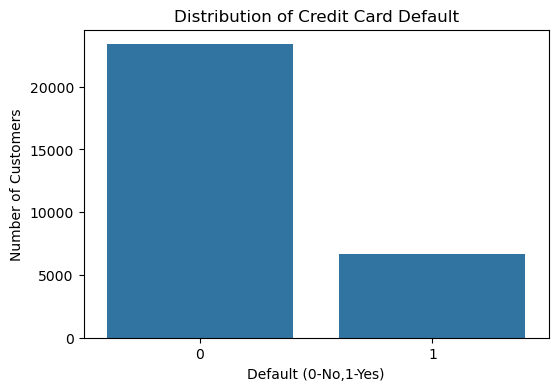

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Default')
plt.title("Distribution of Credit Card Default")
plt.xlabel("Default (0-No,1-Yes)")
plt.ylabel("Number of Customers")
plt.show()

4.2.1 Gender Analysis
----------------------
### Objective

To analyze the distribution of customers based on gender and determine whether default behavior differs between male and female customers.

In [21]:
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [22]:
df['Gender']=df['SEX'].replace({1:'Male',2:'Female'})

In [23]:
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [24]:
df['Gender'].value_counts()

Gender
Female    18112
Male      11888
Name: count, dtype: int64

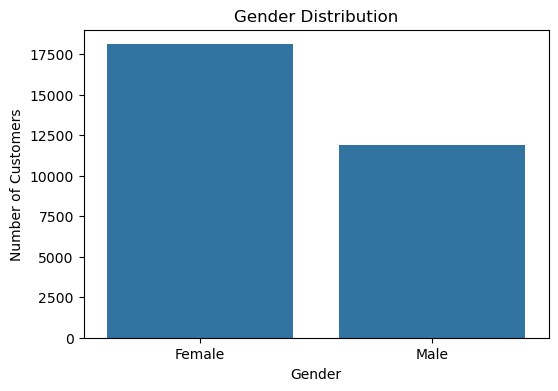

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

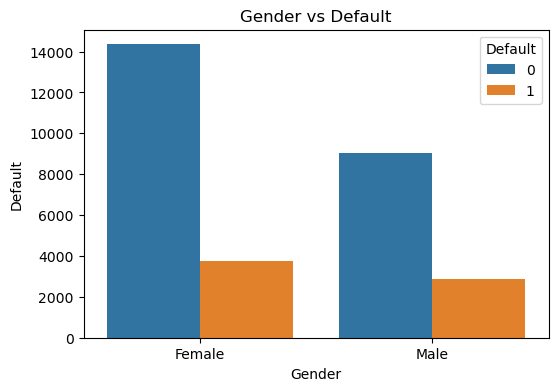

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Gender',hue='Default')
plt.title("Gender vs Default")
plt.xlabel("Gender")
plt.ylabel("Default")
plt.legend(title="Default")
plt.show()

In [27]:
df['Education_Level']=df['EDUCATION'].replace({
    0:'Others',
    1:'Graduate School',
    2:'University',
    3:'High School',
    4:'Others',
    5:'Others',
    6:'Others'
})
df['Marital Status']=df['MARRIAGE'].replace({
    0:'Others',
    1:'Married',
    2:'Single',
    3:'Others'
})

    
    
    

4.2.4 Univariate Analysis
-------------------------

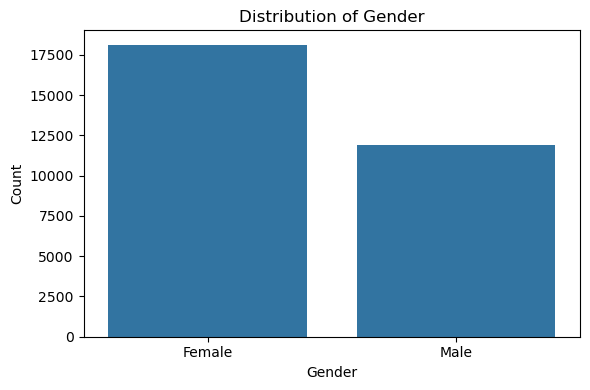

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',data=df)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of Gender")
plt.tight_layout()
plt.show()

Observation
------------
The gender distribution shows that female customers represent a larger proportion of the dataset compared to male customers. However, both categories have a significant representation, indicating that the dataset includes customers from both gender groups.


Business Insight
------------------
Understanding the demographic composition of customers helps financial institutions identify their customer segments and design suitable credit products and services. However, gender alone may not be sufficient to determine credit risk, so its relationship with default behavior will be analyzed separately in the bivariate analysis section.

In [29]:
df['Education_Level'].unique()

array(['University', 'Graduate School', 'High School', 'Others'],
      dtype=object)

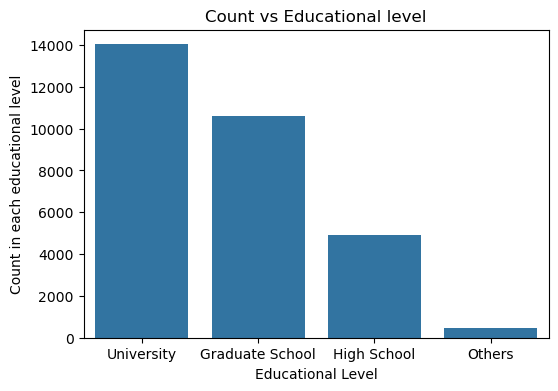

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education_Level',data=df)
plt.title("Count vs Educational level")
plt.xlabel("Educational Level")
plt.ylabel("Count in each educational level")
plt.show()

Observation
-----------
The plot shows that most of the customers belong to the University and Graduate School Level,while others category represents a smaller proportion of the customers

Business Insight
-----------------
Understanding the educational background of customers helps financial institutions understand their customer profile and segment their products accordingly. However, education level alone does not determine credit risk, and its relationship with default behavior will be examined in the bivariate analysis stage.

In [31]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status'],
      dtype='object')

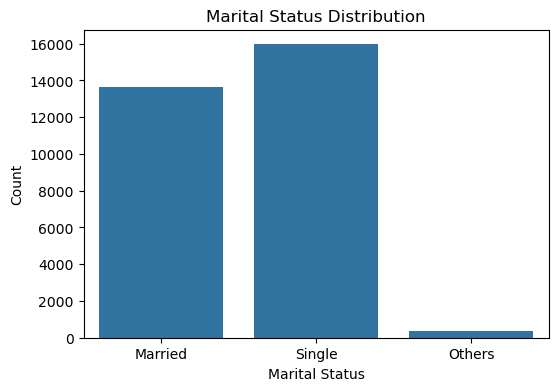

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='Marital Status',data=df)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Marital Status Distribution")
plt.show()

Observation
-----------
When anlaysed the marital status of the most population was found to be single while the least was found to be others

Business Insights
----------------------
Understanding the marital status helps financial institutions understanding the customer profile and segment their products accordingly.Howerver marial status is not the only factor on which the credit risk depends , and it relationship with the default would be examined in the bivariate analysis stage

Objective:
--------------
To understand the distribution of customer ages, identify the dominant age group, detect any unusual values or outliers, and gain insights into the bank's customer demographics.

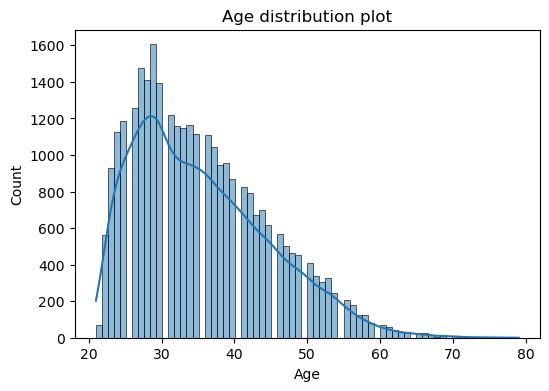

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(x='AGE',kde=True,data=df)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution plot")

plt.savefig("Age distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Observation
--------------
The histogram shows that the highest concentration of customers falls approximately between 25 and 35 years of age, indicating that the bank's credit card customer base is dominated by young to middle-aged adults. The age distribution is positively (right) skewed, with relatively fewer customers in the older age groups.

Business Insights
-----------------
The bank's credit card portfolio is primarily concentrated among young and middle-aged adults, who represent the economically active population. Understanding this customer profile can help the bank design targeted financial products and marketing strategies for its core customer segment.

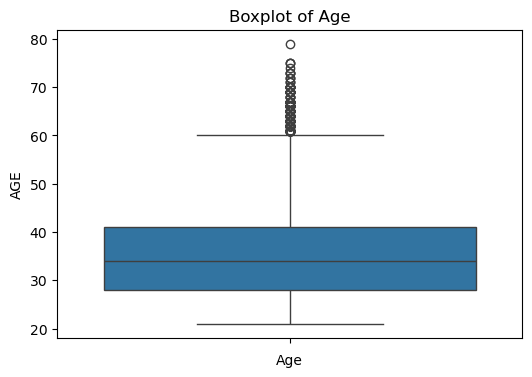

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(y='AGE',data=df)
plt.xlabel('Age')
plt.title("Boxplot of Age")
plt.show()

Observation
--------------
The box plot shows that the median age of customers lies between 30 and 40 years, indicating that half of the customers are younger than the median and half are older. Several observations above approximately 60 years are identified as outliers by the IQR method.

Business Insight
-----------------
The presence of a few elderly customers indicates that the bank's credit card services are used across a wide age range. These customers may represent a niche but valid customer segment, and their records should be retained for analysis.

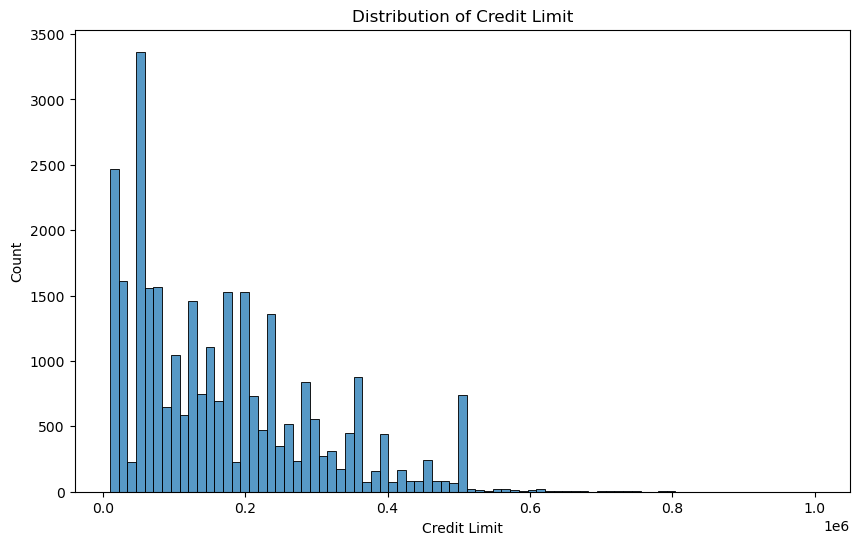

In [50]:
plt.figure(figsize=(10,6))
sns.histplot(x='LIMIT_BAL',data=df)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.savefig("Limit_Balance.png", dpi=300, bbox_inches="tight")
plt.show()

Observation
------------
The distribution of credit limits is positively (right) skewed. Most customers have relatively lower credit limits, while the number of customers decreases as the credit limit increases. A long right tail indicates that only a small proportion of customers have very high credit limits.

Business Insights
-----------------
The distribution indicates that the bank's customer portfolio is primarily composed of customers with lower to moderate approved credit limits, while a smaller segment consists of customers with high credit limits. Understanding this distribution can help the bank evaluate its customer portfolio, design suitable credit products, and develop differentiated strategies for regular and premium customers.


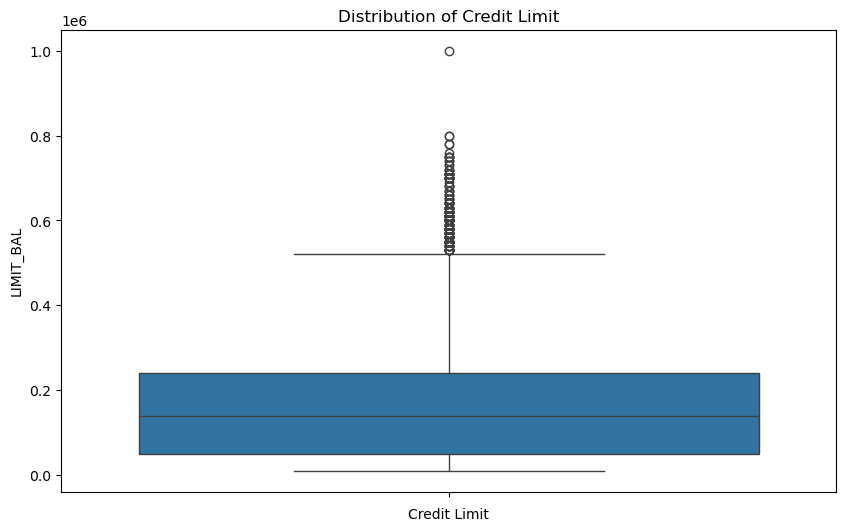

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(y='LIMIT_BAL',data=df)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.show()


Observation
-----------------
The box plot shows that the median credit limit is approximately 140,000, indicating that half of the customers have a credit limit below this value and half have a credit limit above it. The distribution contains several high-value outliers, representing customers with significantly higher credit limits compared to the majority of customers. This confirms that the credit limit distribution is positively skewed.


Business Insights
----------------------
The presence of high credit limit customers indicates that the bank serves different customer segments, including premium customers with higher credit requirements. Instead of uniformly increasing credit limits, the bank can use customer characteristics and repayment behavior to make risk-based credit limit decisions. The identified outliers are retained because they represent genuine high-value customers and may contain important information for predicting default behavior.

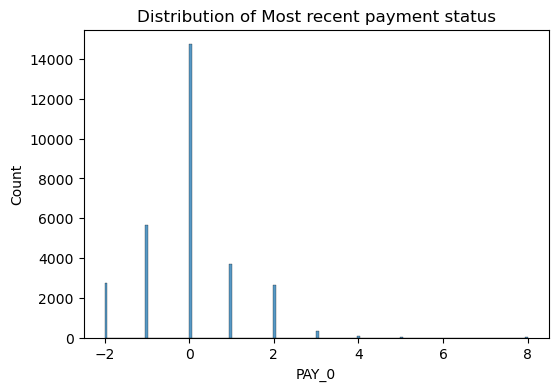

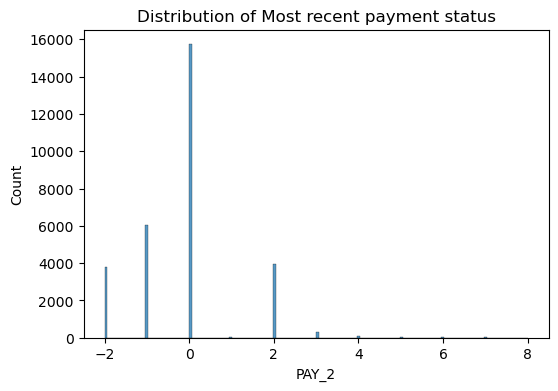

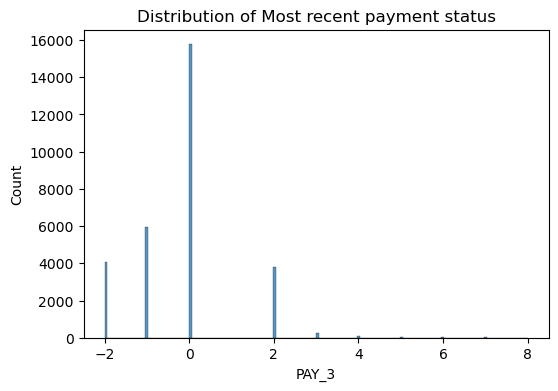

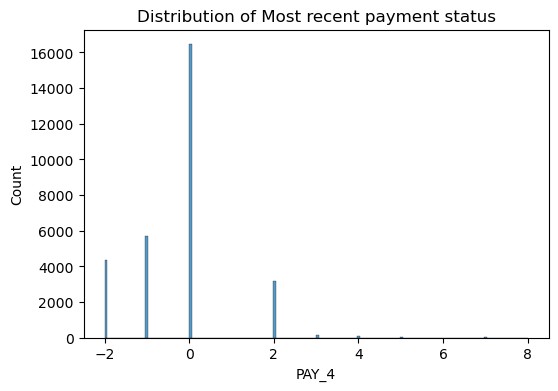

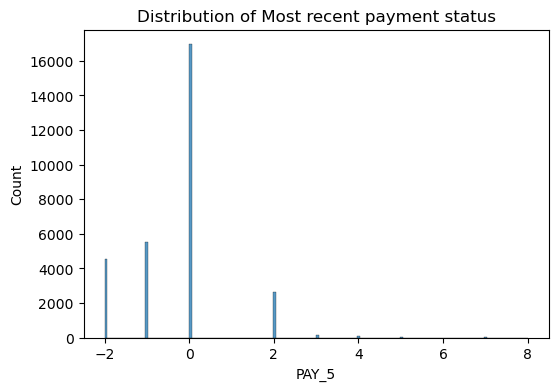

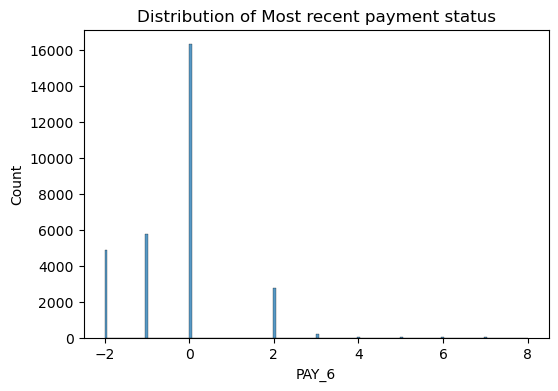

In [52]:
cols=['PAY_0','PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in cols:
    
    plt.figure(figsize=(6,4))
    sns.histplot(x=col,data=df)
    plt.title("Distribution of Most recent payment status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Observation
----------
The repayment status distributions across different months show that the majority of customers fall under categories indicating no payment delay. However, a smaller segment of customers consistently shows delayed payment categories, suggesting the presence of financially stressed customers. The repayment behaviour pattern across months can help identify customers with repeated payment difficulties.



Business Insight
-----------
Repayment history provides valuable information about customer financial discipline. Customers showing repeated delays across multiple months may represent higher-risk segments. The bank can use this information to develop early warning systems, targeted communication, and risk mitigation strategies to reduce potential credit losses.

In [38]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status'],
      dtype='object')

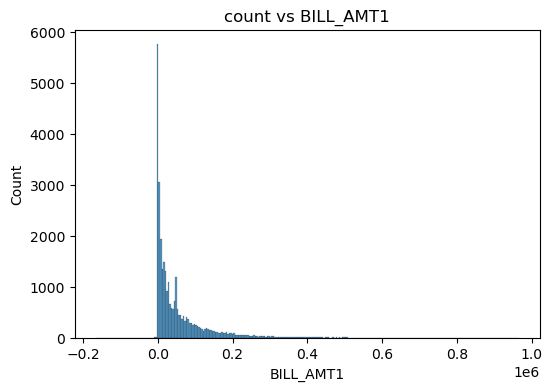

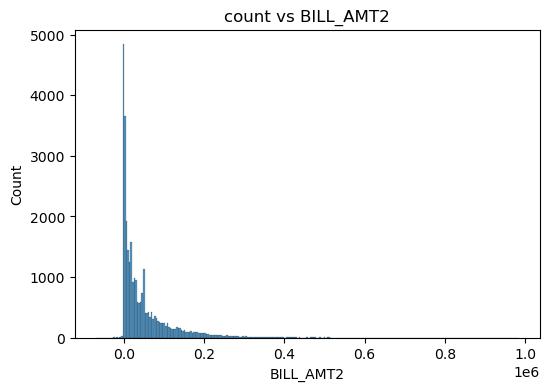

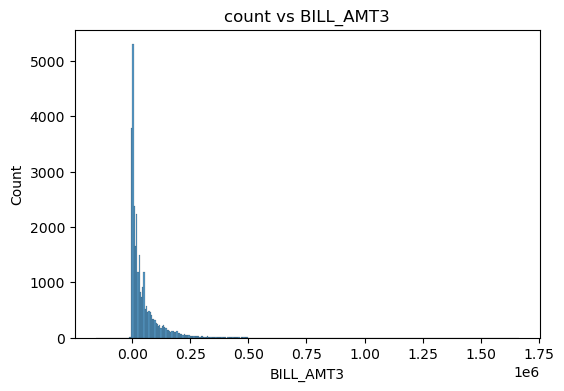

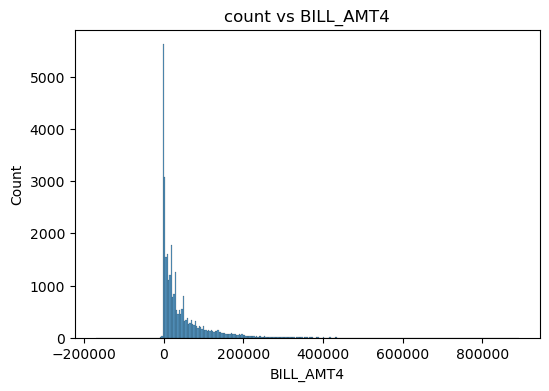

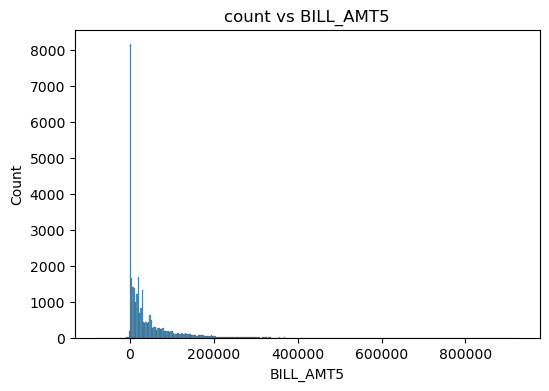

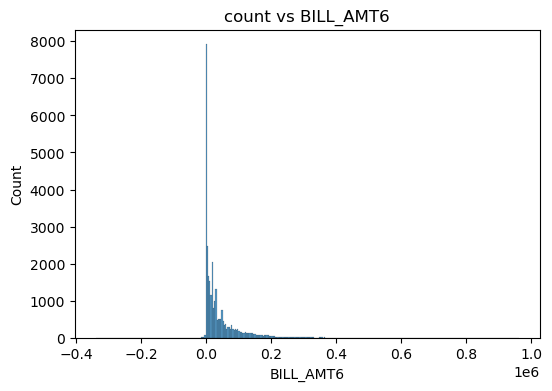

In [39]:
cols=['BILL_AMT1', 'BILL_AMT2','BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=col,data=df)
    plt.title(f"count vs {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    

Observation
-------------
The distributions of the monthly bill amounts are positively (right) skewed across all six months. Most customers have relatively lower monthly statement balances, while a small proportion of customers have substantially higher bill amounts, resulting in a long right tail. The overall distribution appears consistent across the six months, indicating a stable billing pattern.

Business Insights
-------------------
Customers with consistently high monthly bill amounts may represent higher credit utilization and greater financial exposure. Monitoring these customers can help the bank assess credit risk, optimize credit limit management, and identify customers who may require closer financial monitoring.

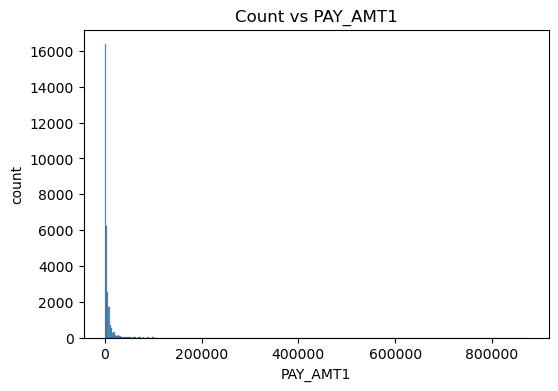

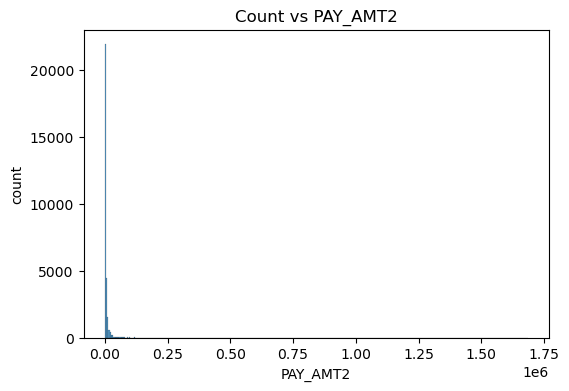

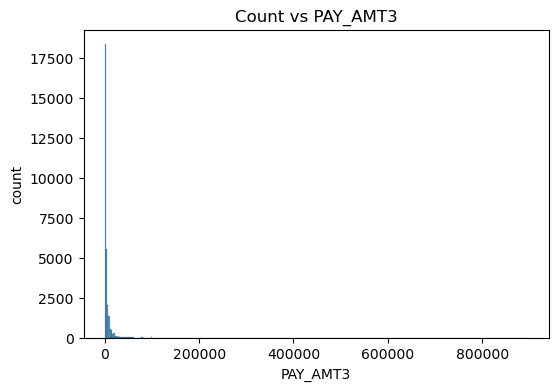

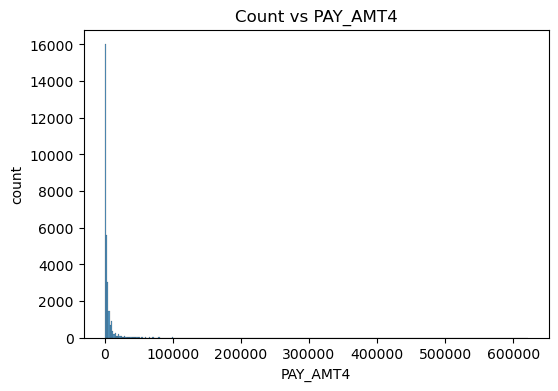

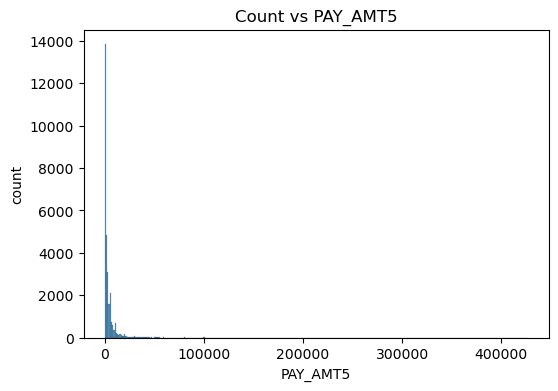

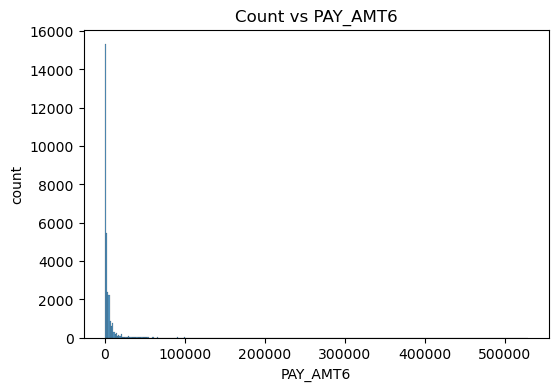

In [40]:
cols=['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=col,data=df)
    plt.title(f"Count vs {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

Observation
------------
The distributions of the monthly amounts are positively (right) skewed across all six months. Most customers have relatively lower monthly payments , while a small proportion of customers have substantially higher monthly payments, resulting in a long right tail. The overall distribution appears consistent across the six months, indicating a stable payment pattern.


Business Insights
----------------
Customers with consistently high payment amounts demonstrate active repayment behaviour and may have larger outstanding balances or higher credit usage. Analyzing payment patterns helps the bank understand customer repayment capacity, evaluate financial behaviour, and support credit risk assessment.

Bivariate Analysis
----------------------

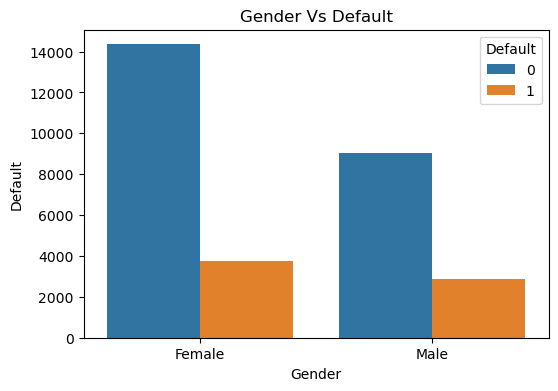

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',hue='Default',data=df)
plt.title("Gender Vs Default")
plt.xlabel("Gender")
plt.ylabel("Default")
plt.savefig("Gender_Default.png", dpi=300, bbox_inches="tight")
plt.show()

Observation
---------------
Female customers have a higher representation in the dataset than male customers. Consequently, the total number of default cases among females is also higher. However, the difference in default counts alone is not sufficient to conclude that gender is a strong predictor of default. A comparison of default rates indicates that gender alone is unlikely to explain customer default behaviour.

Business Insight
------------------
Gender by itself does not appear to provide strong discriminatory power for identifying customers who are likely to default. Therefore, banks should combine demographic information with financial and repayment behaviour variables when assessing credit risk.

Statistical Interpretation
----------------------------
The observed differences between male and female customers are relatively small compared to the overall dataset. This suggests that gender alone is unlikely to be a significant predictor of default and should be evaluated alongside other variables during model building.

In [54]:
df['AGE'].value_counts().sort_index()

AGE
21      67
22     560
23     931
24    1127
25    1186
26    1256
27    1477
28    1409
29    1605
30    1395
31    1217
32    1158
33    1146
34    1162
35    1113
36    1108
37    1041
38     944
39     954
40     870
41     824
42     794
43     670
44     700
45     617
46     570
47     501
48     466
49     452
50     411
51     340
52     304
53     325
54     247
55     209
56     178
57     122
58     122
59      83
60      67
61      56
62      44
63      31
64      31
65      24
66      25
67      16
68       5
69      15
70      10
71       3
72       3
73       4
74       1
75       3
79       1
Name: count, dtype: int64

In [55]:
age_bins = [20, 30, 40, 50, 60, 80]
age_labels = ['21-30', '31-40', '41-50', '51-60', '61+']

df['Age_Group'] = pd.cut(df['AGE'],
                         bins=age_bins,
                         labels=age_labels)

In [56]:
df['Age_Group'].value_counts().sort_index()

Age_Group
21-30    11013
31-40    10713
41-50     6005
51-60     1997
61+        272
Name: count, dtype: int64

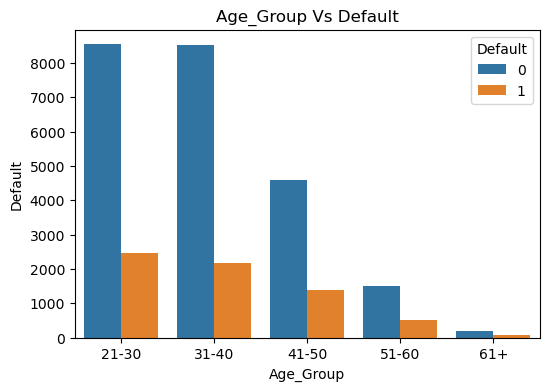

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x='Age_Group',hue='Default',data=df)
plt.title("Age_Group Vs Default")
plt.xlabel("Age_Group")
plt.ylabel("Default")
plt.savefig("Age_goup vs Default",dpi=300,bbox_inches="tight")
plt.show()

Observation
--------------
The group age of '21-30'  has the largets number of customers followed by the group age '31-40'.The group age' 21-30' has the largest number of defaults.

Business Insights
-----------------
Age group alone does not appear sufficient to determine customer default behaviour. However, age segmentation can help the bank understand customer profiles and design targeted risk management strategies when combined with financial and repayment behaviour variables.

Statistical Interpretation
-----------------------------
The difference in default patterns across age groups appears limited based on the visualization. To accurately evaluate whether age group is associated with default, default rates across age categories should be compared rather than only absolute counts.

In [46]:
pd.crosstab(df['Age_Group'], df['Default'], normalize='index') * 100

Default,0,1
Age_Group,,
21-30,77.562880,22.437120
31-40,79.566881,20.433119
41-50,76.702748,23.297252
51-60,74.762143,25.237857
61+,73.161765,26.838235


Observation
--------------
The default rate varies across different age groups. Customers aged 61+ show the highest default rate, followed by the 51–60 age group, while customers in the 31–40 age group show the lowest default rate. Although older age groups show slightly higher default rates, the differences are not very large, indicating that age alone may not be a strong predictor of default behaviour.

Business Insight
--------------------
Age segmentation provides some indication of differences in credit risk, with older customer groups showing relatively higher default rates. However, age should not be used as the sole basis for credit decisions. Banks should combine age information with repayment history, credit utilization, and payment behaviour to develop a more accurate risk assessment strategy.

Statistical Interpretation
----------------------------
The variation in default rates across age groups is relatively moderate, with differences of only a few percentage points between categories. This suggests that Age_Group may provide some predictive information, but it is unlikely to be sufficient as an independent predictor of default. Its contribution should be evaluated along with other financial and behavioural variables during model building.

In [47]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status', 'Age_Group'],
      dtype='object')

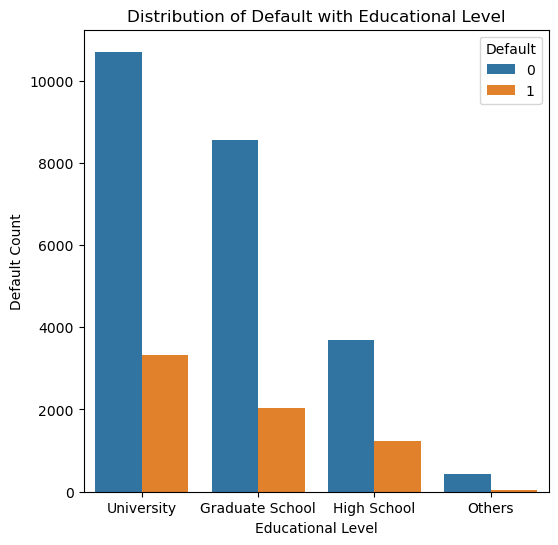

In [48]:
plt.figure(figsize=(6,6))
sns.countplot(x='Education_Level',hue='Default',data=df)
plt.title("Distribution of Default with Educational Level")
plt.xlabel("Educational Level")
plt.ylabel("Default Count")
plt.show()
          

Observation
--------------
Customers with a university education form the largest group in the dataset. Consequently, they also account for the highest number of default cases in absolute terms. However, the count of defaults alone does not indicate that this group has the highest default risk.

Business Insights
------------------
Educational level provides useful demographic information about the customer base. However, it should be used together with financial and repayment behaviour variables when assessing credit risk, rather than being used as an independent indicator of default.

Statistical Interpretation
---------------------------
The count plot indicates differences in customer representation across education levels. Since the categories contain different numbers of customers, default rates should be calculated before concluding whether education level is associated with default risk.

In [49]:
pd.crosstab(df['Education_Level'],df['Default'],normalize='index')*100

Default,0,1
Education_Level,,
Graduate School,80.765234,19.234766
High School,74.842384,25.157616
Others,92.948718,7.051282
University,76.265146,23.734854


Observation
-------------
Customers with a High School education have the highest default rate (25.16%), followed by University graduates (23.73%). Graduate School customers have the lowest default rate among the major education groups (19.23%), while the 'Others' category shows the lowest default rate (7.05%). However, the 'Others' category should be interpreted cautiously, as it may contain relatively few customers.


Business Insights
---------------------
The variation in default rates across education levels suggests that educational background may have some association with repayment behaviour. However, education alone is insufficient for making lending decisions. Banks should combine educational information with financial and repayment history to develop a more reliable credit risk assessment.

Statistical Interpretation
---------------------------
The default rates vary moderately across education levels. High School customers exhibit the highest default rate, while Graduate School customers show a comparatively lower default rate. Although education appears to have some relationship with default behaviour, the differences are not substantial enough to conclude that education alone is a strong predictor of default. Its predictive value should be evaluated together with financial and behavioural variables during model building.

In [50]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status', 'Age_Group'],
      dtype='object')

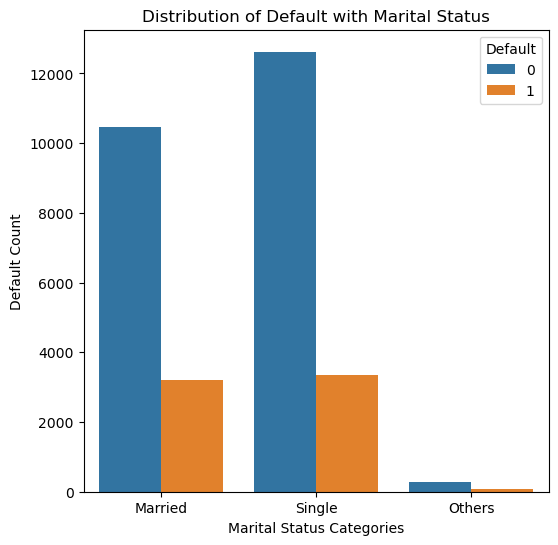

In [51]:
plt.figure(figsize=(6,6))
sns.countplot(x='Marital Status',hue='Default',data=df)
plt.title("Distribution of Default with Marital Status")
plt.xlabel("Marital Status Categories")
plt.ylabel("Default Count")
plt.show()

Observation
-----------------
Single customers form the largest customer group in the dataset, followed by married customers, while the 'Others' category has the smallest representation. Consequently, the single category also contributes the largest number of default cases in absolute terms.



Business Insights
---------------------
Marital status provides demographic information that may help the bank understand its customer base. However, lending decisions should not rely solely on marital status and should instead incorporate financial and repayment behaviour variables for accurate credit risk assessment.


Statistical Interpretation
--------------------------
The count plot reflects differences in customer representation across marital status categories. Since the categories contain different numbers of customers, default rates should be compared before determining whether marital status is associated with default risk.

In [52]:
pd.crosstab(df['Marital Status'],df['Default'],normalize='index')*100

Default,0,1
Marital Status,,
Married,76.528296,23.471704
Others,76.392573,23.607427
Single,79.071661,20.928339


Observation
----------------
The default rates are fairly similar across the marital status categories. The 'Others' category has the highest default rate (23.61%), closely followed by Married customers (23.47%), while Single customers have a comparatively lower default rate (20.93%). Overall, the differences between the groups are relatively small.

Business Insights
-----------------
Marital status alone does not appear to strongly influence customer default behaviour. Although slight differences exist across the categories, banks should rely more on customers' financial characteristics and repayment history rather than marital status when assessing credit risk.


Statistical Interpretation
------------------------
The variation in default rates across marital status categories is relatively small, with the highest and lowest rates differing by less than three percentage points. This suggests that marital status has limited predictive power on its own and should be considered alongside other demographic, financial, and behavioural variables during model development.

Summary of Demographic Analysis:
---------------------------------------
The demographic variables show some variation in default rates across different customer groups. However, the differences are generally moderate, indicating that demographic characteristics alone are insufficient for accurately predicting credit default. Therefore, financial attributes and repayment behaviour are expected to play a more significant role in credit risk assessment and model performance.

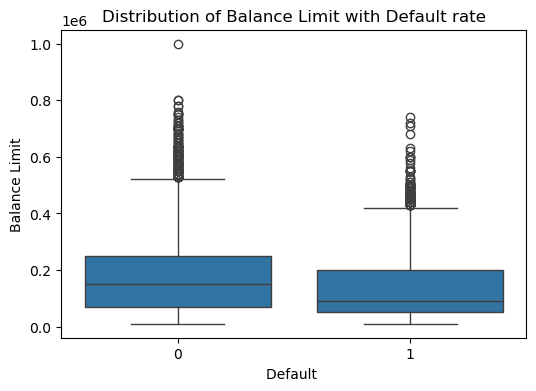

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(y='LIMIT_BAL',x='Default',data=df)
plt.title("Distribution of Balance Limit with Default rate")
plt.ylabel("Balance Limit")
plt.xlabel("Default ")
plt.show()

observation
-------------
The median line of the non default rate is higher than that of the default rate.And there are oultiers in both the sysytems

Business Insight
------------------
Customers with lower credit limits show a relatively higher tendency towards default in this dataset. However, credit limit alone should not be considered sufficient for credit risk assessment. Banks should combine credit limit information with repayment history, outstanding balances, and payment behaviour to make better lending decisions.

Statistical Interpretation
-------------------------------
The difference in median credit limits between defaulting and non-defaulting customers suggests that LIMIT_BAL may have some predictive value. However, the considerable overlap between the two distributions indicates that it is not a strong standalone predictor and should be evaluated along with other financial and behavioural variables during model building.


In [54]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status', 'Age_Group'],
      dtype='object')

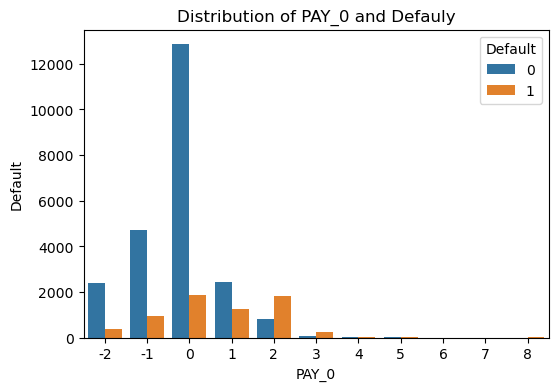

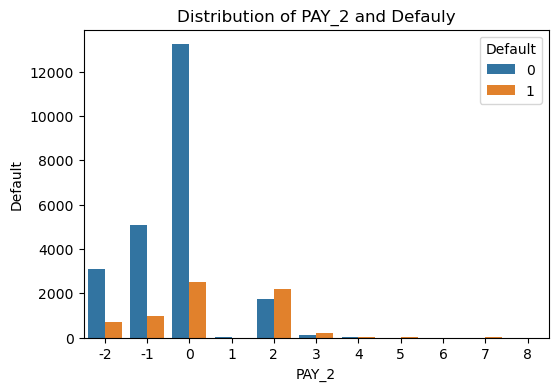

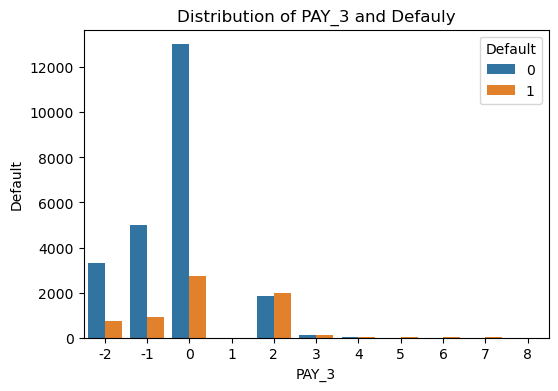

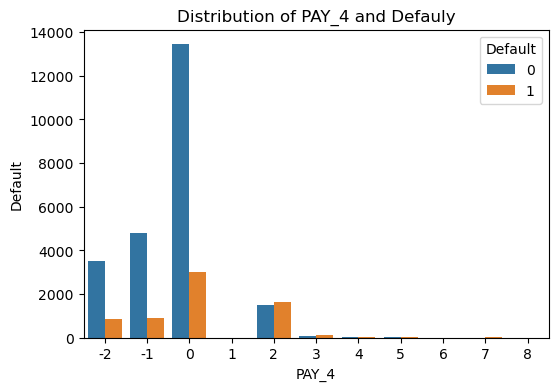

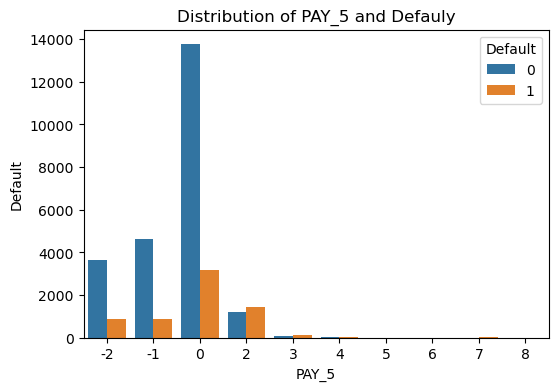

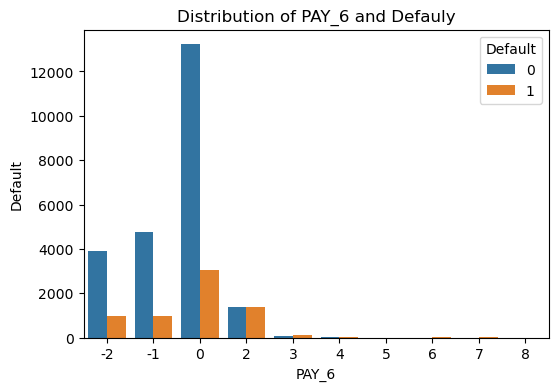

In [55]:
cols=['PAY_0', 'PAY_2','PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,hue='Default',data=df)
    plt.title(f"Distribution of {col} and Defauly")
    plt.xlabel(col)
    plt.ylabel("Default")
    plt.show()

Observation
--------------
The repayment status distribution shows that most customers belong to the categories indicating no payment delay or timely repayment behaviour. However, customers with delayed repayment statuses also contribute a noticeable number of default cases. This indicates that repayment behaviour may have a relationship with credit default.

Business Insight
-----------------
Repayment history provides valuable information about customer financial discipline. Customers showing delayed payment behaviour may represent higher-risk segments, allowing banks to implement early warning systems, payment reminders, and closer credit monitoring to reduce potential credit losses.

Statistical Interpretation
----------------------------
The count plots indicate that repayment status categories are distributed differently among defaulting and non-defaulting customers. However, since the categories have different customer volumes, default rates for each repayment status category should be calculated to accurately measure the strength of association between repayment behaviour and default.

In [56]:
pd.crosstab(df['PAY_0'], df['Default'], normalize='index')*100

Default,0,1
PAY_0,,
-2,86.770569,13.229431
-1,83.221949,16.778051
0,87.188709,12.811291
1,66.052061,33.947939
2,30.858643,69.141357
3,24.223602,75.776398
4,31.578947,68.421053
5,50.000000,50.000000
6,45.454545,54.545455


Observation
----------

The default rate varies significantly across different repayment status categories. Customers with no payment delay (PAY_0 = 0) show a relatively low default rate of 12.81%, whereas customers with delayed payments show considerably higher default rates. The default rate increases sharply for customers with severe repayment delays, reaching above 69% for PAY_0 = 2 and above 75% for PAY_0 = 3 and PAY_0 = 7. This indicates a strong relationship between repayment history and default behaviour.

Business Insight
--------------

Repayment behaviour is a critical indicator of credit risk. Customers showing delayed payment patterns represent high-risk segments and require closer monitoring. Banks can use repayment history to develop early warning systems, send timely payment reminders, provide financial assistance programs, and adjust credit policies to reduce future defaults.

Statistical Interpretation
----------------------------

PAY_0 demonstrates a strong association with default risk. The default rate increases substantially as repayment delays increase, suggesting that recent repayment status has significant predictive value. Unlike demographic variables, which showed relatively small differences in default rates, repayment behaviour creates clear separation between defaulting and non-defaulting customers. Therefore, PAY_0 is expected to be an important feature during machine learning model development.

In [57]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status', 'Age_Group'],
      dtype='object')

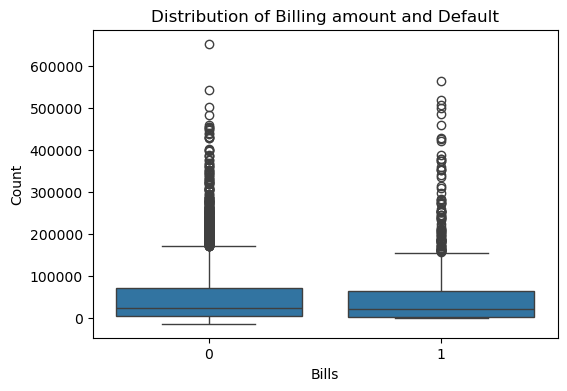

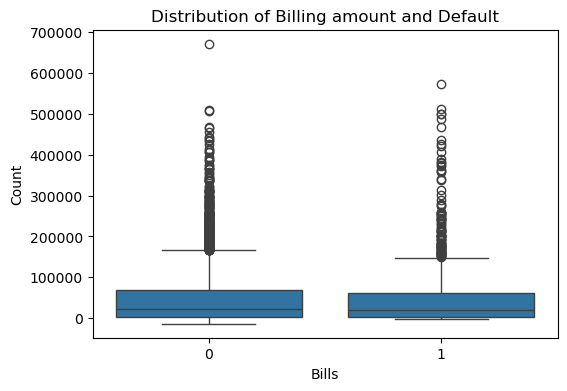

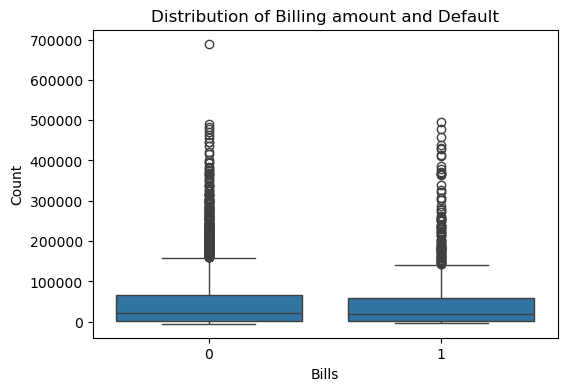

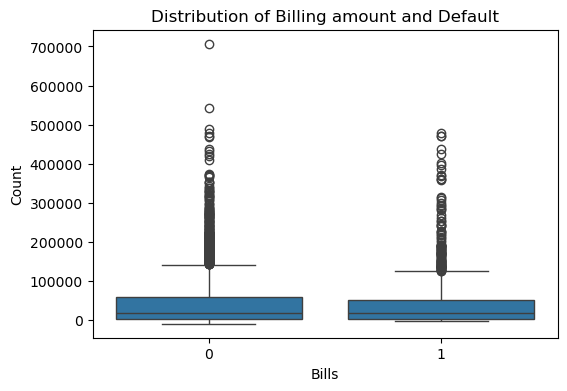

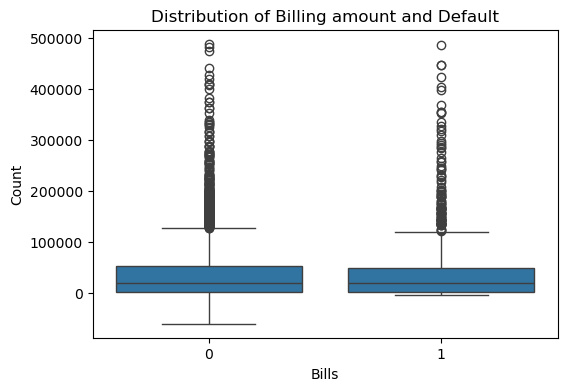

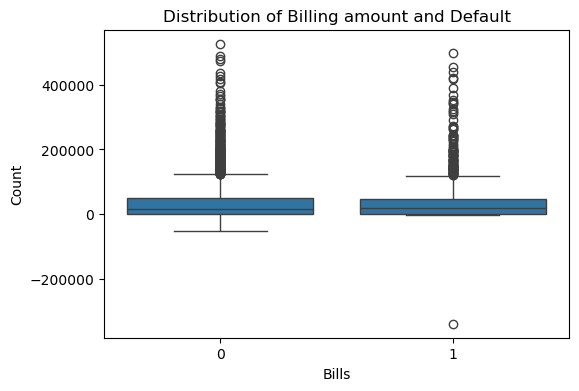

In [58]:
cols=['BILL_AMT1', 'BILL_AMT2','BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for col in cols: 
    plt.figure(figsize=(6,4)) 
    sns.boxplot(y=col, x='Default',data=df.sample(5000, random_state=42)) 
    plt.title("Distribution of Billing amount and Default") 
    plt.xlabel("Bills")
    plt.ylabel("Count") 
    plt.show()

Observation
-------------
The monthly bill amount distributions show the outstanding balances of customers across six months. The median bill amounts between defaulting and non-defaulting customers show some differences, but considerable overlap exists between the two groups. Several high-value outliers are present, representing customers with unusually large outstanding balances.

Business Insight
-------------------
Monthly bill amounts help the bank understand customers' outstanding financial exposure. Customers with consistently high outstanding balances may require closer monitoring; however, bill amount alone may not be sufficient to identify default risk because repayment behaviour and other financial factors also influence default.

Statistical Interpretation
-----------------------------
The overlap between defaulting and non-defaulting customers suggests that bill amounts have some predictive information but may not be a strong standalone predictor. Their contribution should be evaluated along with repayment history and other financial variables during model development.

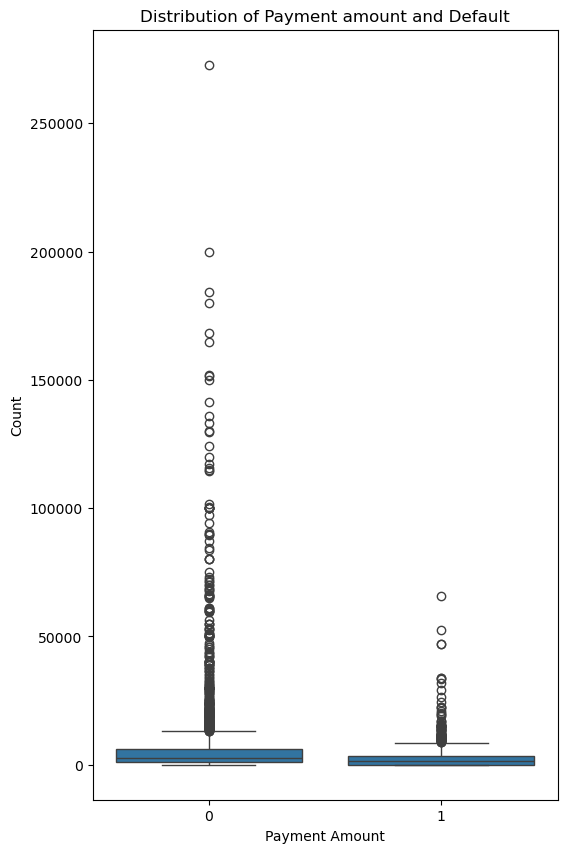

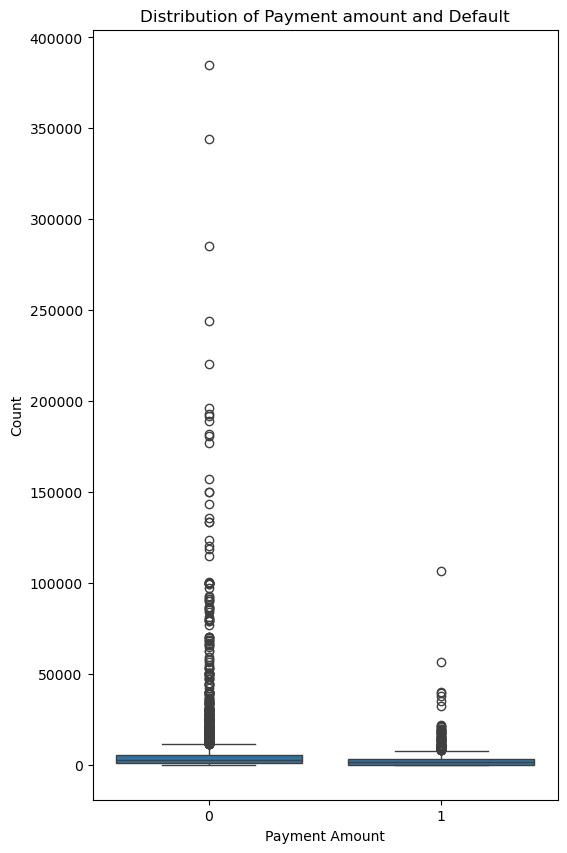

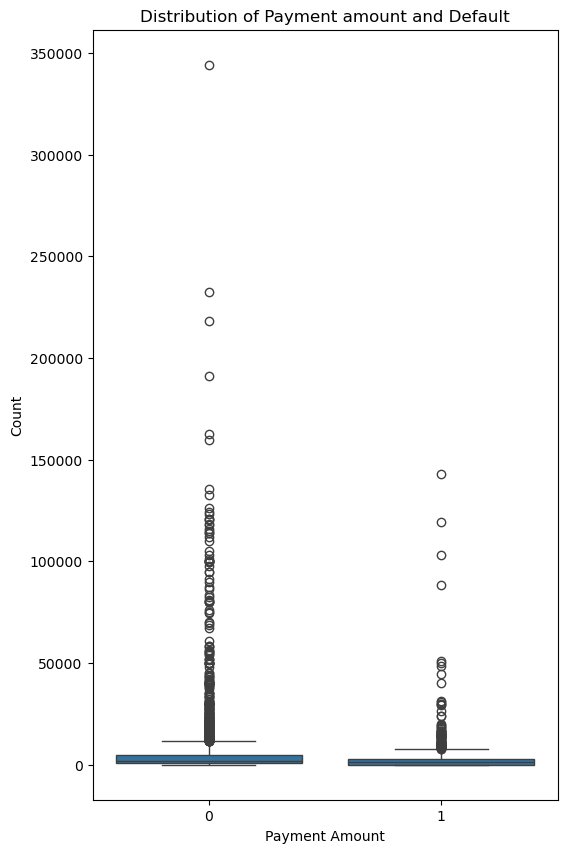

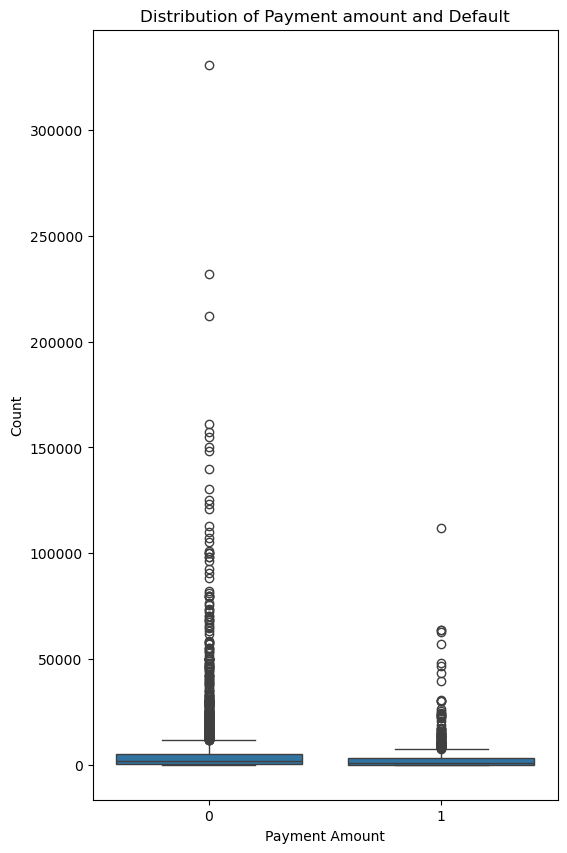

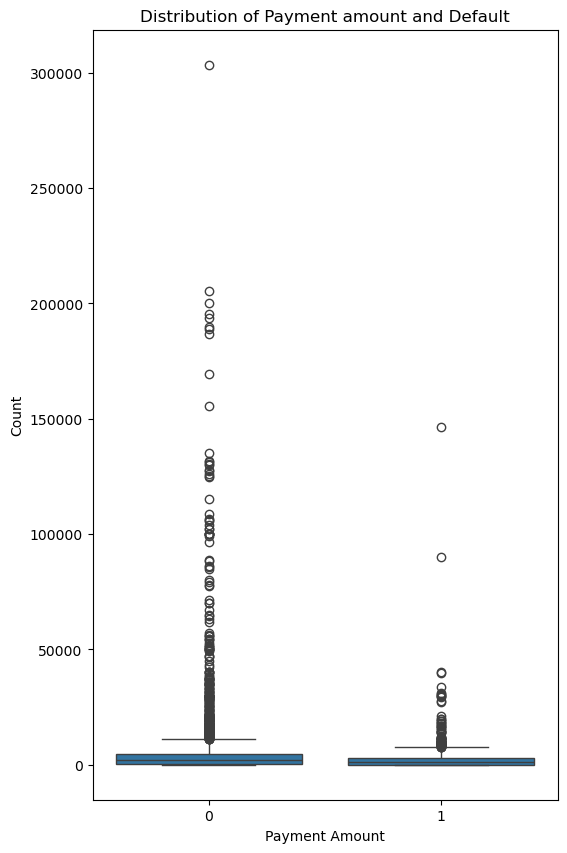

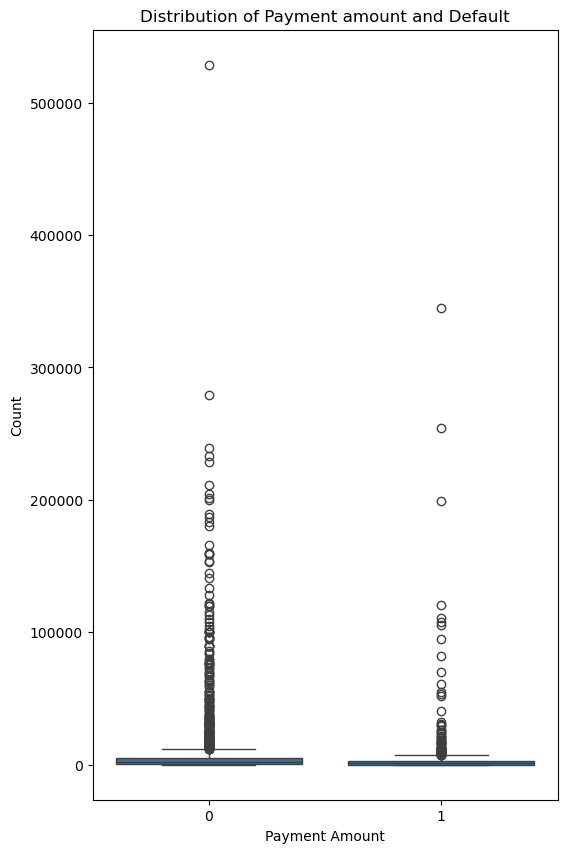

In [59]:
cols=['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for col in cols: 
    plt.figure(figsize=(6,10)) 
    sns.boxplot(y=col, x='Default',data=df.sample(5000, random_state=42)) 
    plt.title("Distribution of Payment amount and Default") 
    plt.xlabel("Payment Amount")
    plt.ylabel("Count") 
    plt.show()

Observation
-------------
The box plots of monthly payment amounts show that non-defaulting customers generally have a slightly higher median payment amount compared to defaulting customers across the six months. This suggests that customers who make higher repayments may have better repayment capacity. However, significant overlap exists between the two groups, indicating that payment amount alone does not completely distinguish defaulters from non-defaulters.

Business Insight
------------------
Monthly payment amounts provide insights into customers' repayment capacity and financial discipline. Customers making consistently lower payments may represent higher-risk segments and require closer monitoring. Banks can use payment behaviour along with repayment history and outstanding balances to improve credit risk assessment.

Statistical Interpretation
------------------------------
The difference in median payment amounts between defaulting and non-defaulting customers indicates that PAY_AMT variables may contain some predictive information. However, the overlapping distributions suggest that payment amount alone is not a strong predictor of default. It should be combined with other important variables, especially repayment status variables, during model development.

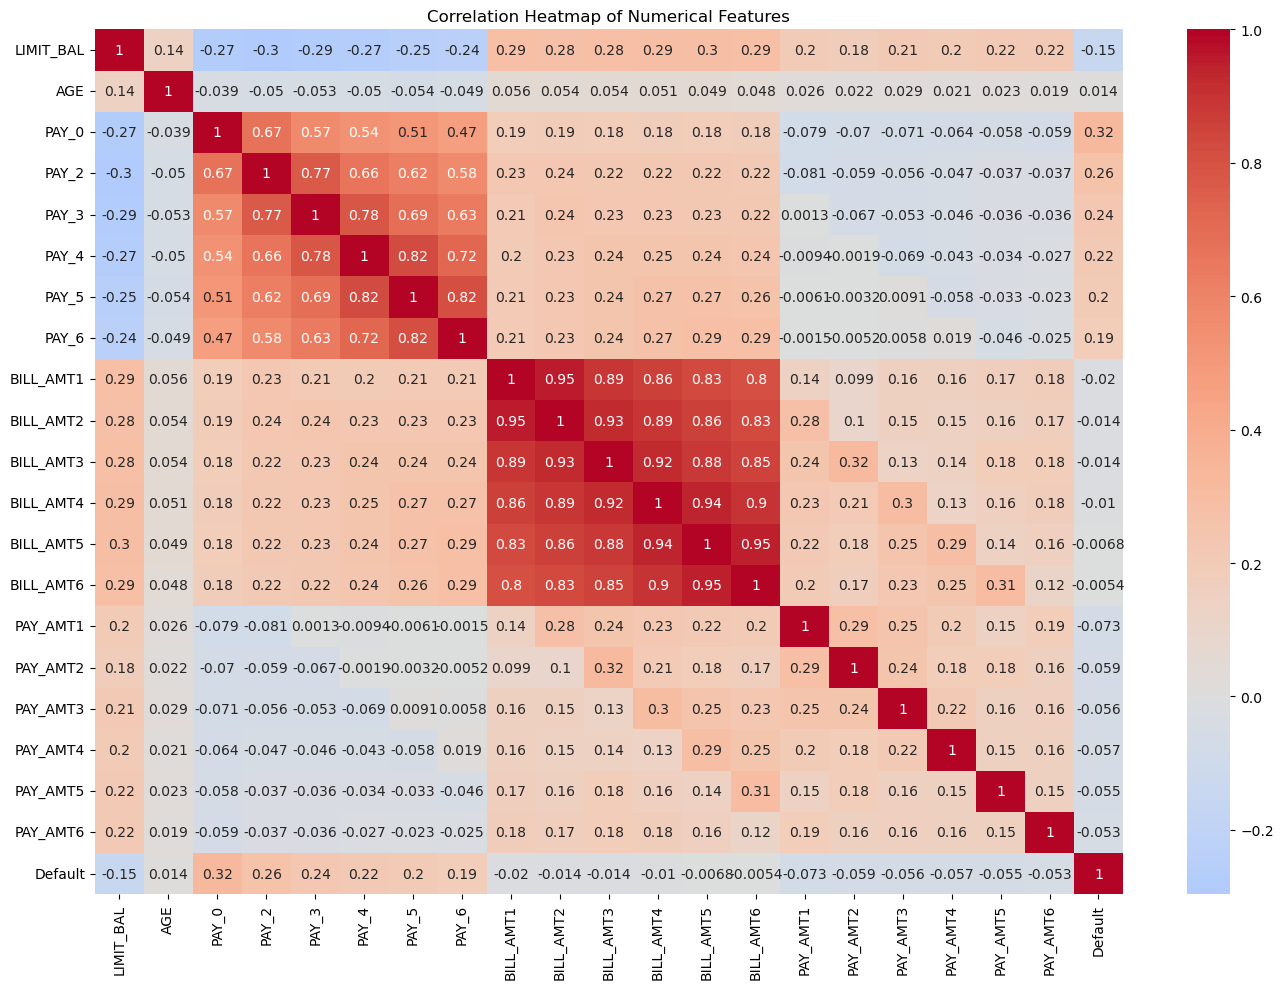

In [61]:
numeric_cols = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'Default'
]

plt.figure(figsize=(14, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    cmap='coolwarm',
    center=0,
    annot=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("Correlation Heatmap",dpi=300,bbox_inches="tight")
plt.show()

Observation
-------------

The heatmap shows the correlation among numerical variables. Consecutive repayment status variables (PAY_0 to PAY_6) exhibit relatively strong positive correlations with one another. Similarly, billing amount variables (BILL_AMT1 to BILL_AMT6) and payment amount variables (PAY_AMT1 to PAY_AMT6) show positive correlations across successive months. The target variable (Default) has a stronger positive relationship with repayment status variables than with demographic variables.

Business Insight
--------------------

Customers with a history of delayed repayments tend to exhibit a higher likelihood of default. The strong relationships among billing and payment variables suggest consistent spending and repayment patterns over time. These insights support the use of historical repayment behaviour as a key factor in credit risk assessment.

Statistical Interpretation
------------------------------

No severe multicollinearity is observed across all numerical variables, although monthly repayment status, billing amounts, and payment amounts are naturally correlated because they represent sequential monthly observations. The moderate correlation between repayment history and the target variable supports its predictive value, which is further confirmed by the Random Forest feature importance analysis.

Final EDA Summary
---------------------
Exploratory Data Analysis revealed several important patterns in the dataset. Demographic variables such as gender, age, education level, and marital status showed only moderate differences in default rates, indicating that they are not strong standalone predictors of default. Financial variables provided more meaningful insights. Customers with lower credit limits generally exhibited a higher tendency to default, while repayment history showed the strongest relationship with default behaviour. Customers with delayed repayments had substantially higher default rates than those who made timely payments. Overall, repayment behaviour emerged as the most influential factor in assessing credit risk, suggesting that financial and behavioural variables are expected to contribute more significantly than demographic characteristics during machine learning model development.

In [60]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'Gender', 'Education_Level', 'Marital Status', 'Age_Group'],
      dtype='object')

In [61]:
df.drop(columns='Age_Group',inplace=True)

In [62]:
df.drop(columns='Gender',inplace=True)

In [63]:
df.drop(columns='Education_Level',inplace=True)

In [64]:
df.drop(columns='Marital Status',inplace=True)

In [65]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default'],
      dtype='object')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

In [67]:
X=df.drop(columns='Default')
y=df['Default']

In [68]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [71]:
X_train.shape

(24000, 23)

In [72]:
X_test.shape

(6000, 23)

In [73]:
y_train.value_counts()

Default
0    18691
1     5309
Name: count, dtype: int64

In [74]:
y_test.value_counts()

Default
0    4673
1    1327
Name: count, dtype: int64

In [75]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_trained_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [76]:
type(X_test_scaled)

numpy.ndarray

Model 1: Logistic Regression
-------------------------------

In [77]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced',random_state=42)
model.fit(X_trained_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [78]:
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score,precision_score
print("Classification Matrix:",classification_report(y_test,y_pred))
print("Confusion_ matrix:",confusion_matrix(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Precision Score:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
from sklearn.metrics import recall_score, roc_auc_score
print("Recall Score:", recall_score(y_test,y_pred))
y_prob = model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test,y_prob))

      

Classification Matrix:               precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

Confusion_ matrix: [[3255 1418]
 [ 504  823]]
Accuracy Score: 0.6796666666666666
Precision Score: 0.36724676483712626
F1 Score: 0.461322869955157
Recall Score: 0.6201959306706858
ROC-AUC Score: 0.7081149369197677


Interpretation:
---------------
3255 customers were correctly identified as non-defaulters.
823 customers were correctly identified as potential defaulters.
1418 customers were incorrectly classified as defaulters (False Positives).
504 customers who actually defaulted were missed by the model (False Negatives).

Business Interpretation
------------------------
For a credit risk problem, identifying potential defaulters is more important than achieving high accuracy.
The Logistic Regression model achieved:
Recall of 62% for default customers, meaning it successfully identified around 62% of actual defaulters.
This is useful because the bank can intervene with these customers through:
payment reminders,
credit monitoring,
repayment assistance programs.
However, the model still missed around 38% of actual defaulters, which indicates room for improvement.

Statistical Interpretation
---------------------------

The ROC-AUC score of 0.708 indicates that the model has a reasonable ability to distinguish between default and non-default customers.

However:

Precision is relatively low (36.7%).
This means many customers predicted as defaulters were actually non-defaulters.

This suggests that while Logistic Regression captures some default patterns, the relationship between customer characteristics and default behaviour is not completely linear.

Model Conclusion
------------------
Logistic Regression was used as the baseline classification model. The model achieved an accuracy of approximately 68% and ROC-AUC of 0.708. By applying class weighting, the model was able to improve detection of the minority default class, achieving a recall of 62%. However, the relatively low precision indicates that several customers were incorrectly classified as defaulters. This suggests that default behaviour may involve complex non-linear relationships, and tree-based ensemble models may provide better predictive performance.

Model 2: Decision Tree Classifier
----------------------------------

In [79]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)

In [80]:
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("Precision Score:", precision_score(y_test, y_pred_dt))
print("Recall Score:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      4673
           1       0.37      0.41      0.39      1327

    accuracy                           0.71      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.71      0.72      6000

Confusion Matrix:
 [[3741  932]
 [ 781  546]]
Accuracy Score: 0.7145
Precision Score: 0.36941813261163736
Recall Score: 0.4114544084400904
F1 Score: 0.3893048128342246
ROC-AUC Score: 0.6074506323181914


Observation 
------------------------
The Decision Tree model achieved an accuracy of 71.45%, which is higher than Logistic Regression. However, it identified fewer default customers, resulting in a recall of only 41.15%. This indicates that the model missed a larger number of actual defaulters despite having a higher overall accuracy.

Business Insight
----------------

Although the Decision Tree improved overall accuracy, it failed to identify many customers who actually defaulted. In a banking environment, missing high-risk customers can lead to financial losses. Therefore, a model with higher recall for the default class is generally preferred over one with higher accuracy alone.

Statistical Interpretation
------------------------

Compared with Logistic Regression, the Decision Tree produced a lower recall, F1-score, and ROC-AUC score. This suggests that the default Decision Tree does not generalize well for identifying default customers and may require hyperparameter tuning to improve its predictive performance.

Hyperparameter Tuned Decision Tree
------------------------------------


In [81]:
dt_tuned=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_tuned.fit(X_train,y_train)
y_pred_tuned=dt_tuned.predict(X_test)

In [82]:
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("Accuracy Score:", accuracy_score(y_test, y_pred_tuned))
print("Precision Score:", precision_score(y_test, y_pred_tuned))
print("Recall Score:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

y_prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_tuned))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

Confusion Matrix:
 [[4431  242]
 [ 855  472]]
Accuracy Score: 0.8171666666666667
Precision Score: 0.6610644257703081
Recall Score: 0.3556895252449133
F1 Score: 0.46251837334639884
ROC-AUC Score: 0.7423241082064694


Observation
--------------

After tuning the Decision Tree by limiting its maximum depth, the model achieved a significantly higher accuracy (81.72%) and precision (66.11%) compared to the default Decision Tree. The ROC-AUC score also improved from 0.607 to 0.742, indicating better discrimination between default and non-default customers. However, the recall decreased to 35.57%, meaning the model identified fewer actual defaulters.

Business Insight
-------------------
The tuned Decision Tree generates fewer false alarms by predicting default more accurately (higher precision). However, it misses a larger proportion of actual defaulters because of its lower recall. In a banking environment, this trade-off should be carefully considered. If minimizing financial loss from undetected defaulters is the priority, a model with higher recall may still be preferable.

Statistical Interpretation
-----------------------------
Hyperparameter tuning reduced the complexity of the Decision Tree, leading to improved generalization. This is reflected in the higher accuracy, precision, F1-score, and ROC-AUC score. However, the decrease in recall indicates that the simpler model became more conservative when predicting defaults.

Model 3: Random Forest Classifier
------------------------------------

In [83]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Precision Score:", precision_score(y_test, y_pred_rf))
print("Recall Score:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

y_prob_rf = rf_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

Confusion Matrix:
 [[4397  276]
 [ 852  475]]
Accuracy Score: 0.812
Precision Score: 0.6324900133155792
Recall Score: 0.3579502637528259
F1 Score: 0.4571703561116458
ROC-AUC Score: 0.7505958244954782


Interpretation:
-------------
4397 customers were correctly identified as non-defaulters.
475 customers were correctly identified as defaulters.
276 safe customers were incorrectly classified as defaulters.
852 actual defaulters were missed.

Observation
--------------
Random Forest achieved an accuracy of 81.2% and a ROC-AUC score of 0.751, showing good capability in distinguishing between default and non-default customers. The model achieved higher precision compared to Logistic Regression, indicating fewer false default predictions. However, the recall for the default class remained low at approximately 36%, meaning a significant number of actual defaulters were still not detected.

Business Insight
---------------------

Random Forest provides a better balance between overall prediction performance and reduction of false alarms. However, from a banking perspective, missing potential defaulters remains a concern because undetected risky customers may result in financial losses. Therefore, recall should be considered along with accuracy before selecting the final model.

Statistical Interpretation
------------------------------

The Random Forest model performed better than the individual Decision Tree, particularly in terms of ROC-AUC, demonstrating that ensemble learning improved the model's ability to distinguish between customer risk categories. However, the model remained conservative in predicting defaults, resulting in lower recall.

In [85]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
class_weight='balanced'
rf_tuned=RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)
grid_search=GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
best_rf=grid_search.best_estimator_
y_pred_rf_tuned=best_rf.predict(X_test)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [86]:
best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

In [87]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_tuned))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision Score:", precision_score(y_test, y_pred_rf_tuned))
print("Recall Score:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf_tuned))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000

Confusion Matrix:
 [[3973  700]
 [ 577  750]]
Accuracy Score: 0.7871666666666667
Precision Score: 0.5172413793103449
Recall Score: 0.5651846269781462
F1 Score: 0.5401512423478574
ROC-AUC Score: 0.7738085082399475


Final Model Justification
------------------------------
Among all the machine learning models evaluated, the Tuned Random Forest was selected as the final model. Although Logistic Regression achieved the highest recall, the Tuned Random Forest provided the best overall balance between precision and recall, resulting in the highest F1-score and ROC-AUC score. This indicates superior capability in distinguishing default and non-default customers while maintaining robust predictive performance. Therefore, the Tuned Random Forest is the most suitable model for supporting credit risk assessment.

In [88]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.244857
6,PAY_2,0.097277
8,PAY_4,0.060318
7,PAY_3,0.059081
0,LIMIT_BAL,0.048565
10,PAY_6,0.043154
18,PAY_AMT2,0.041467
17,PAY_AMT1,0.040786
11,BILL_AMT1,0.037728
19,PAY_AMT3,0.036594


In [89]:
feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.244857
6,PAY_2,0.097277
8,PAY_4,0.060318
7,PAY_3,0.059081
0,LIMIT_BAL,0.048565
10,PAY_6,0.043154
18,PAY_AMT2,0.041467
17,PAY_AMT1,0.040786
11,BILL_AMT1,0.037728
19,PAY_AMT3,0.036594


Observation
-------------

The most influential feature in predicting credit default is PAY_0 (most recent repayment status), contributing approximately 24.5% of the total feature importance. Other repayment history variables such as PAY_2, PAY_3, PAY_4, and PAY_6 also rank among the top predictors. Financial variables including LIMIT_BAL, PAY_AMT1, PAY_AMT2, PAY_AMT3, and BILL_AMT1 contribute moderately to the prediction.

Business Insight
----------------

The results indicate that customers' recent repayment behaviour is the strongest indicator of future default. Customers who have recently delayed repayments are significantly more likely to default again. Credit limit and payment amount also influence risk, but repayment history carries much greater predictive power. Banks can use these findings to develop early warning systems, identify high-risk customers, and implement proactive measures such as payment reminders, credit monitoring, or revised credit limits.

Statistical Interpretation
-----------------------------

The Random Forest model assigns the highest importance to repayment status variables, demonstrating that historical payment behaviour has greater predictive value than demographic characteristics or credit limit alone. This suggests that behavioural variables provide stronger discrimination between defaulting and non-defaulting customers.

Final Project Conclusion
----------------------------
This project developed a machine learning model to predict whether a credit card customer is likely to default on the next month's payment. The dataset was preprocessed through data cleaning, feature engineering, encoding, train-test splitting, and feature scaling where appropriate. Exploratory Data Analysis revealed that repayment history, credit limit, billing amounts, and payment amounts were strongly associated with customer default behaviour.

Multiple machine learning models, including Logistic Regression, Decision Tree, Tuned Decision Tree, Random Forest, and Tuned Random Forest, were developed and evaluated. Among these, the Tuned Random Forest achieved the best overall performance with a ROC-AUC score of 0.774, F1-score of 0.540, and Recall of 56.5%, providing the most balanced predictive capability for identifying default risk.

Feature importance analysis further confirmed that recent repayment behaviour is the most influential factor in predicting customer default. These findings can assist financial institutions in improving credit risk assessment, strengthening early warning systems, and making more informed lending decisions.

Business Recommendations
-------------------------------
#1)We have to monitor repayment behaviour regularly, especially recent payment delays (PAY_0 and PAY_2), as they are the strongest indicators of default risk.
#2)We have to implement early intervention strategies such as reminders or repayment assistance for customers showing delayed payments.
#3)We have to review credit limits for customers with repeated repayment delays and high outstanding balances.
#4)We have to use the Tuned Random Forest model as a decision-support tool to identify high-risk customers before extending additional credit.
#5)We have to periodically retrain the model using recent customer data to maintain predictive performance as customer behaviour changes over time.
